## Visualização dados

Nesse notebook é reproduzido o gráfico da transição religiosa no Brasil entre 1872 e 2022 com base nas boas práticas de visualização de dados

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from utils.load_csv import load_csv
from utils.save_graph import save_graph

In [2]:
df = load_csv('dados_religioes_brasil.csv')

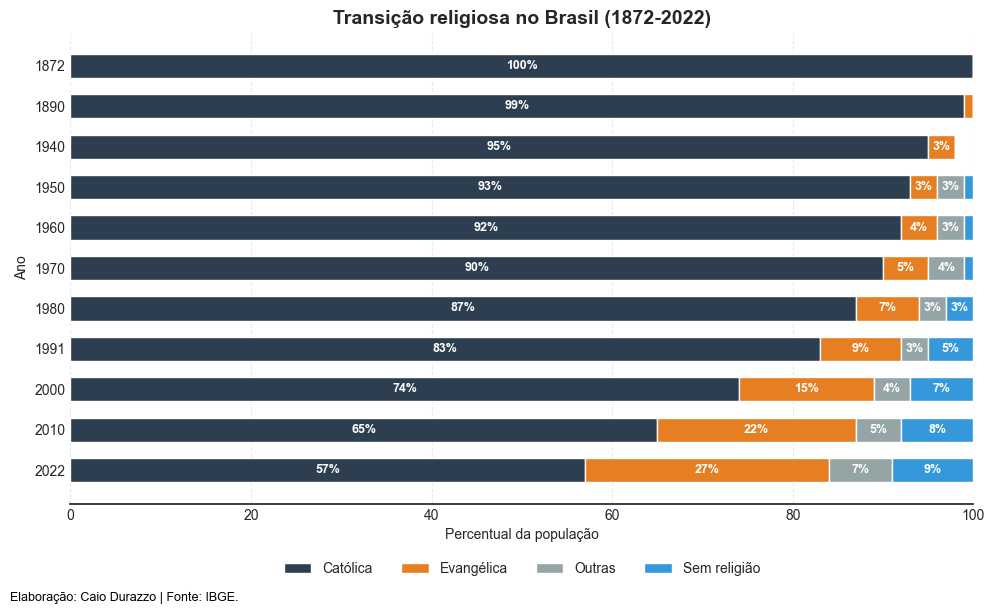

In [3]:
plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(10,6))

cores = {
    "Católica":"#2C3E50",
    "Evangélica":"#E67E22",
    "Outras":"#95A5A6",
    "Sem religião":"#3498DB"
}

y_pos = np.arange(len(df))
left = np.zeros(len(df))

for religiao in cores:

    valores = df[religiao]

    bars = ax.barh(
        y_pos,
        valores,
        left=left,
        color=cores[religiao],
        edgecolor="white",
        height=0.6,
        label=religiao
    )

    for i, v in enumerate(valores):
        if v >= 3:
            ax.text(
                left[i] + v/2,
                y_pos[i],
                f"{v:.0f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                weight="bold"
            )

    left += valores

ax.set_xlim(0,100)

ax.set_xlabel("Percentual da população")
ax.set_ylabel("Ano")

ax.set_yticks(y_pos)
ax.set_yticklabels(df["Ano"])

ax.invert_yaxis()

ax.set_title(
    "Transição religiosa no Brasil (1872-2022)",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.legend(
    ncol=4,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5,-0.18)
)

fig.text(
    0.01, -0.01,
    "Elaboração: Caio Durazzo | Fonte: IBGE.",
    ha="left",
    fontsize=9,
    color="black"
)

plt.tight_layout()
plt.show()

In [4]:
save_graph(fig, "transicao_religiosa_brasil.png")